# Training

In [7]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r'C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\data\processed\dry_beans_clean.csv')
df.head()

X = df.drop(columns="Class")
y = df["Class"]

# Entrenamiento - Modelo Baseline

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.2,
random_state=42,
stratify=y
)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

baseline_model = Pipeline(steps=[
("scaler", StandardScaler()),
("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline = f1_score(y_test, y_pred_baseline, average="macro")
print("Accuracy baseline:", accuracy_baseline)
print("F1 macro baseline:", f1_baseline)
print(classification_report(y_test, y_pred_baseline))

Accuracy baseline: 0.9191583610188261
F1 macro baseline: 0.9302365421734592
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



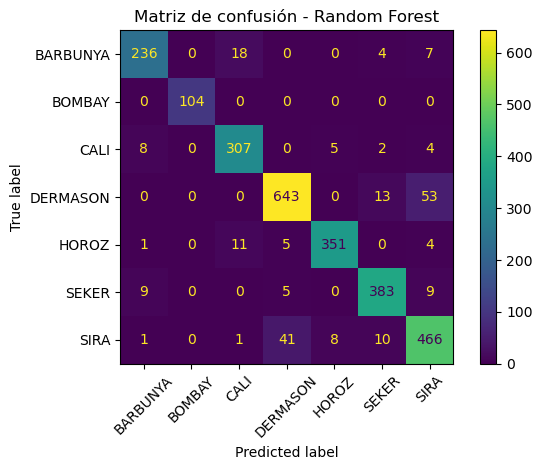

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test,
y_pred_baseline,
xticks_rotation=45
)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

## Entrenamiento - Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
n_estimators=200,
random_state=42,
class_weight="balanced"
)
forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)
accuracy_forest = accuracy_score(y_test, y_pred_forest)
f1_forest = f1_score(y_test, y_pred_forest, average="macro")
print("Accuracy Random Forest:", accuracy_forest)
print("F1 macro Random Forest:", f1_forest)
print(classification_report(y_test, y_pred_forest))

Accuracy Random Forest: 0.9191583610188261
F1 macro Random Forest: 0.9303396642494651
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.89      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.95      0.95       372
       SEKER       0.95      0.95      0.95       406
        SIRA       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



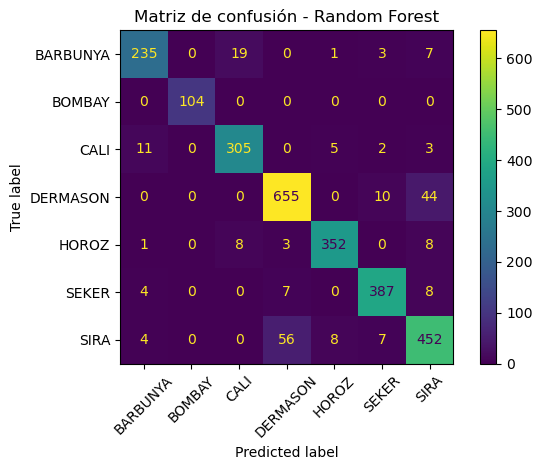

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test,
y_pred_forest,
xticks_rotation=45
)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

# Comparación de Resultados

In [13]:
results = pd.DataFrame({
"modelo": ["Logistic Regression", "Random Forest"],
"accuracy": [accuracy_baseline, accuracy_forest],
"f1_macro": [f1_baseline, f1_forest]
})
print(results)

                modelo  accuracy  f1_macro
0  Logistic Regression  0.919158  0.930237
1        Random Forest  0.919158  0.930340


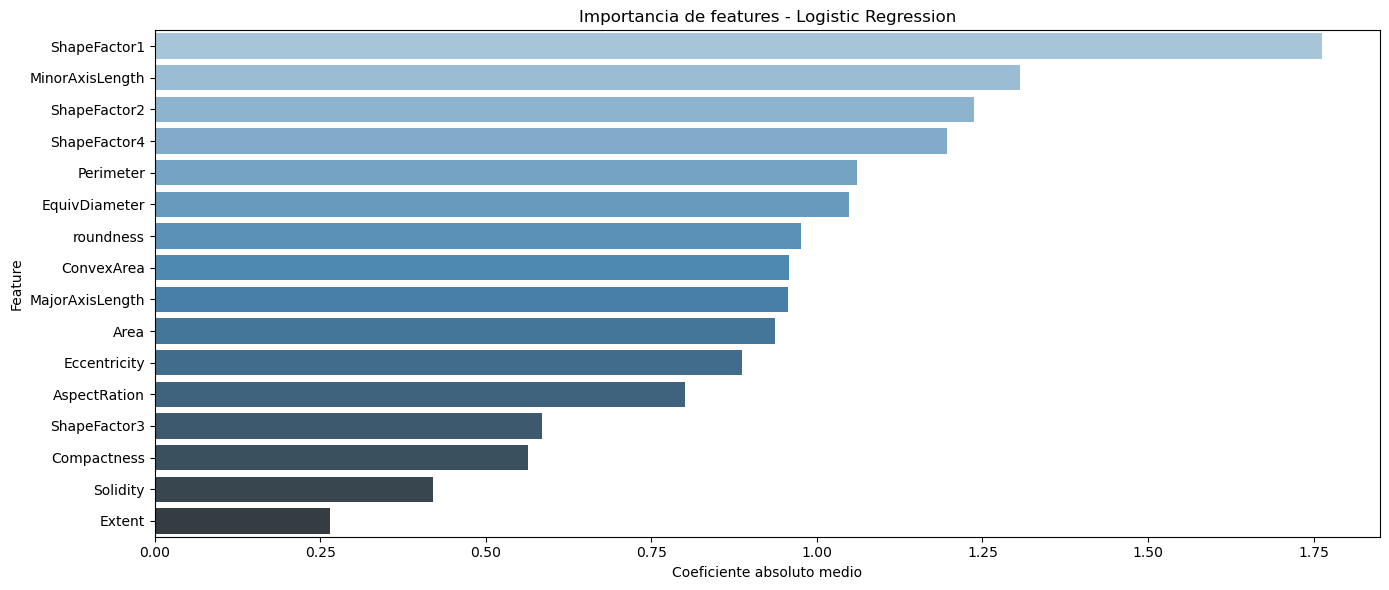

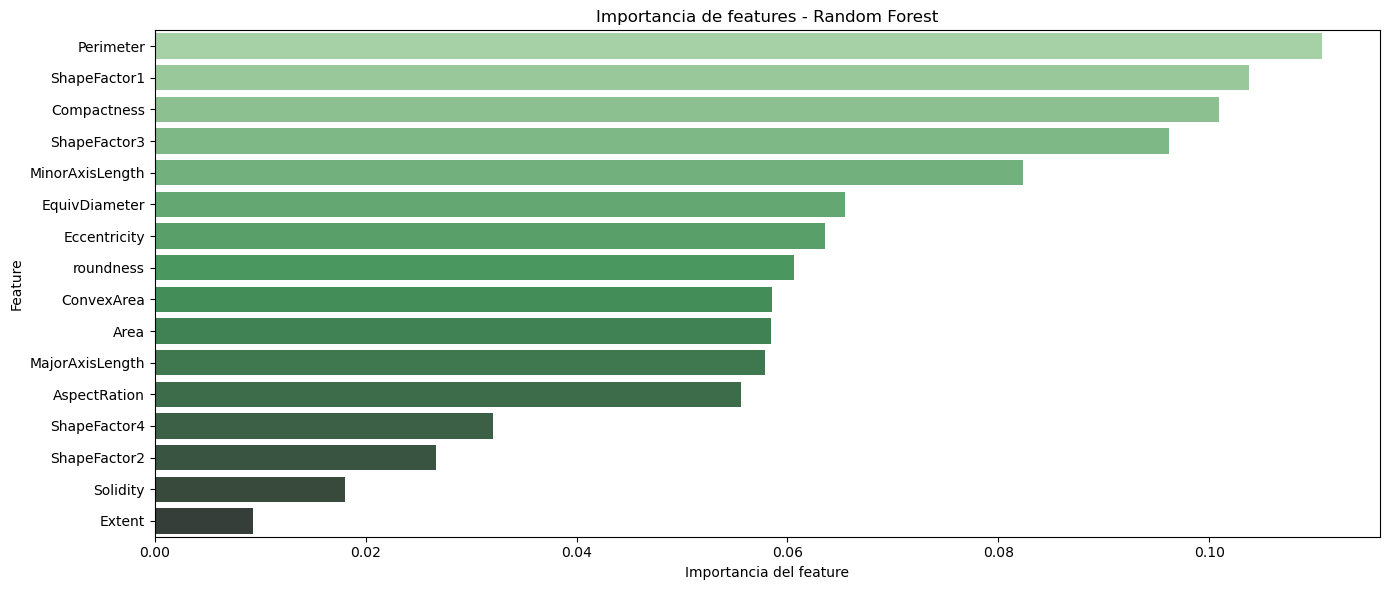

Top 10 Logistic Regression
            feature  importance
12     ShapeFactor1    1.762288
3   MinorAxisLength    1.306633
13     ShapeFactor2    1.236723
15     ShapeFactor4    1.195814
1         Perimeter    1.061153
7     EquivDiameter    1.048376
10        roundness    0.976702
6        ConvexArea    0.957632
2   MajorAxisLength    0.956463
0              Area    0.936185

Top 10 Random Forest
            feature  importance
1         Perimeter    0.110657
12     ShapeFactor1    0.103784
11      Compactness    0.100960
14     ShapeFactor3    0.096224
3   MinorAxisLength    0.082303
7     EquivDiameter    0.065410
5      Eccentricity    0.063603
10        roundness    0.060583
6        ConvexArea    0.058514
0              Area    0.058437


In [17]:
import numpy as np
import seaborn as sns
lr_coefs = np.mean(np.abs(baseline_model.named_steps["classifier"].coef_), axis=0)

importance_lr = pd.DataFrame({
    "feature": X.columns,
    "importance": lr_coefs
}).sort_values("importance", ascending=False)

importance_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_lr, x="importance", y="feature", palette="Blues_d")
plt.title("Importancia de features - Logistic Regression")
plt.xlabel("Coeficiente absoluto medio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_rf, x="importance", y="feature", palette="Greens_d")
plt.title("Importancia de features - Random Forest")
plt.xlabel("Importancia del feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Logistic Regression")
print(importance_lr.head(10))

print("\nTop 10 Random Forest")
print(importance_rf.head(10))


# Guardar Modelos

In [19]:
import joblib
joblib.dump(baseline_model, r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\outputs\models\reports\baseline_model.joblib")
joblib.dump(forest_model, r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\outputs\models\reports\random_forest_model.joblib")

['C:\\UAO\\Gestion IA y DC\\laboratorio_drybean_ml\\outputs\\models\\reports\\random_forest_model.joblib']